In [1]:
import numpy as np
import mujoco as mj
import os


Video shape: (240, 256, 256, 3), Frame shape: (256, 256, 3), Tracks shape: (240, 34, 3)
[[[  0.  92.  16.]
  [  0.  95.  19.]
  [  0.  99.  22.]
  ...
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]]

 [[  1.  89.  17.]
  [  1.  93.  21.]
  [  1.  97.  24.]
  ...
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]]

 [[  2.  89.  18.]
  [  2.  93.  23.]
  [  2.  97.  26.]
  ...
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]]

 ...

 [[237.  75. 157.]
  [237.  82. 161.]
  [237.  89. 164.]
  ...
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]]

 [[238.  76. 163.]
  [238.  83. 166.]
  [238.  90. 168.]
  ...
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]]

 [[239.  76. 171.]
  [239.  83. 173.]
  [239.  91. 174.]
  ...
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]
  [ -1.  -1.  -1.]]]
[[ 91.  16.]
 [ 95.  20.]
 [ 99.  23.]
 [103.  27.]
 [107.  30.]
 [111.  33.]
 [116.  36.]
 [120.  38.]
 [125.  41.]
 [130.  42.]
 [135.  44.]
 [140.  45.]
 [145.  45.]
 [150

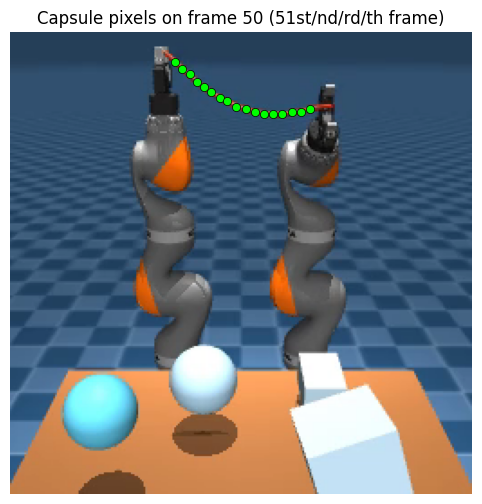

In [2]:
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt
tracks = np.load("data/teleop_rope_tracks_txy.npy")   # shape: (T, N_capsules, 3) -> [frame, x, y]
video = media.read_video("data/teleop_front_camera.mp4")  # adjust path if needed


frame_idx = 50
img = video[frame_idx]
print(f"Video shape: {video.shape}, Frame shape: {img.shape}, Tracks shape: {tracks.shape}")
xy = tracks[frame_idx, :, 1:3]   # x, y for all capsules
print(tracks)
# keep only valid coordinates
h, w = img.shape[:2]
valid = (
    (xy[:, 0] >= 0) & (xy[:, 0] < w) &
    (xy[:, 1] >= 0) & (xy[:, 1] < h)
)
xy = xy[valid]
print(xy)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.scatter(xy[:, 0], xy[:, 1], s=35, c="lime", edgecolors="black", linewidths=0.5)
plt.title(f"Capsule pixels on frame {frame_idx} ({frame_idx + 1}st/nd/rd/th frame)")
plt.axis("off")
plt.show()